In [96]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [97]:
full_df = pd.DataFrame()
for dir in os.listdir('.'):
    if dir.endswith('.csv') and 'full' not in dir:
        df = pd.read_csv(dir)
        full_df = pd.concat([full_df, df], ignore_index=True)

full_df = full_df.fillna('')
full_df['title_length'] = full_df['title'].apply(lambda x: len(x.split()))

/var/folders/6q/yjm90tjx6td5_1v23jrh5nyc0000gn/T/ipykernel_51157/1501581934.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dir)


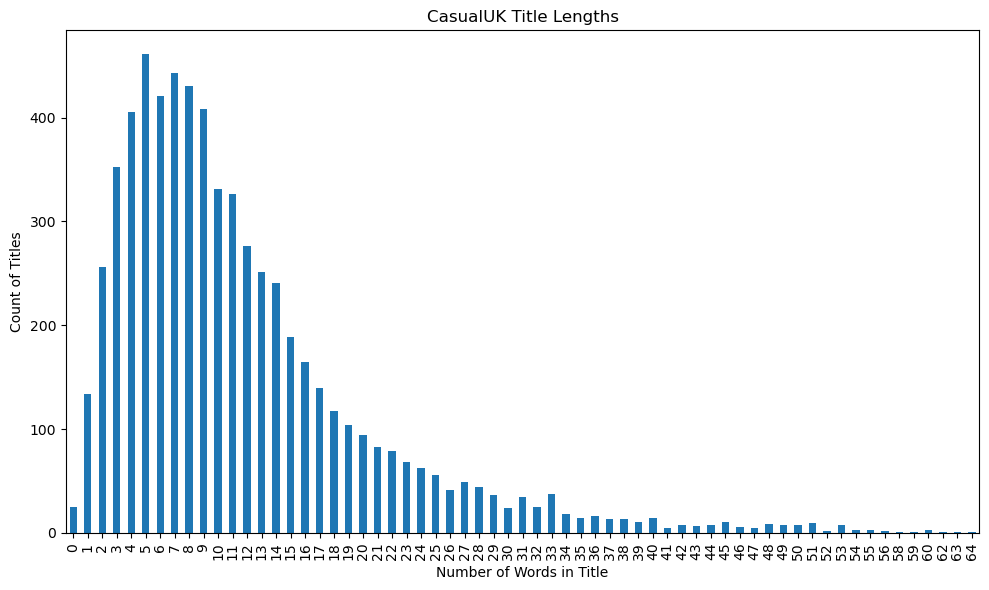

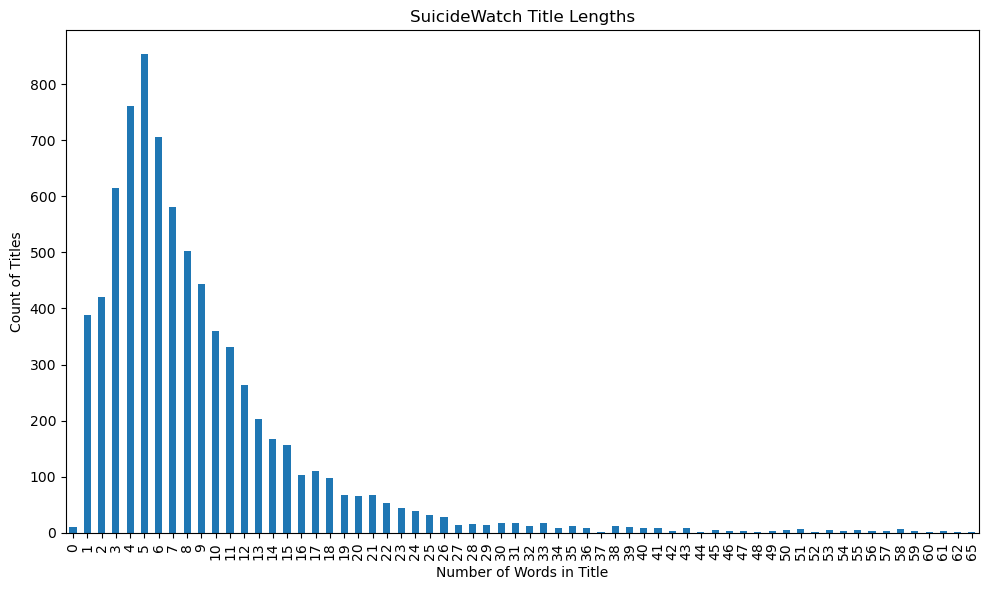

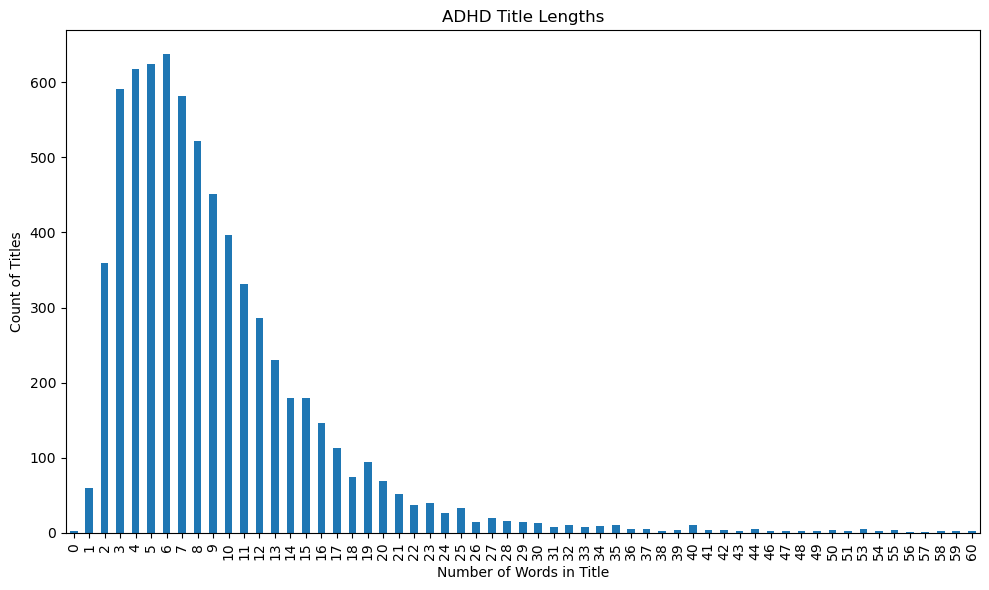

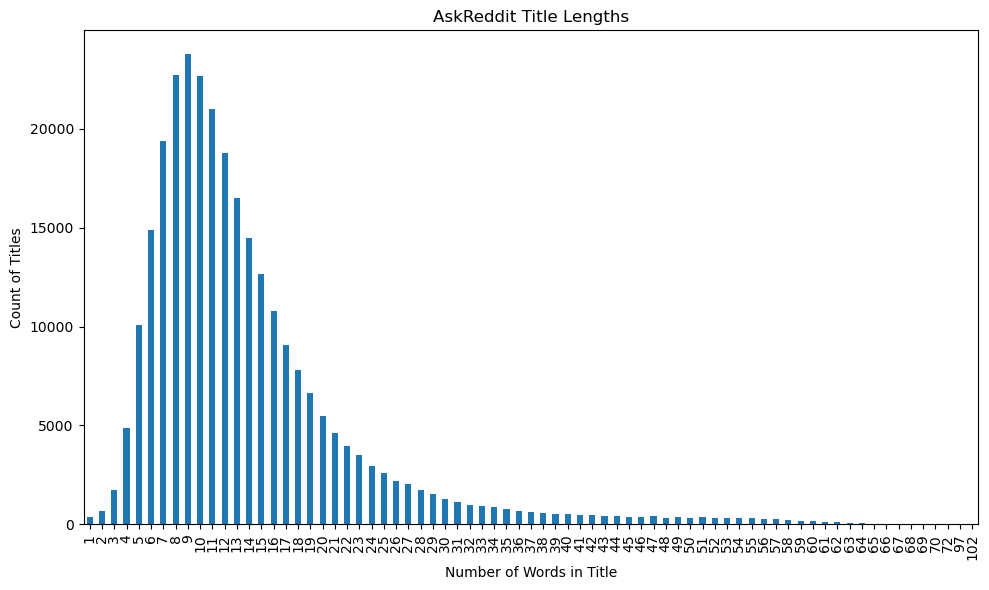

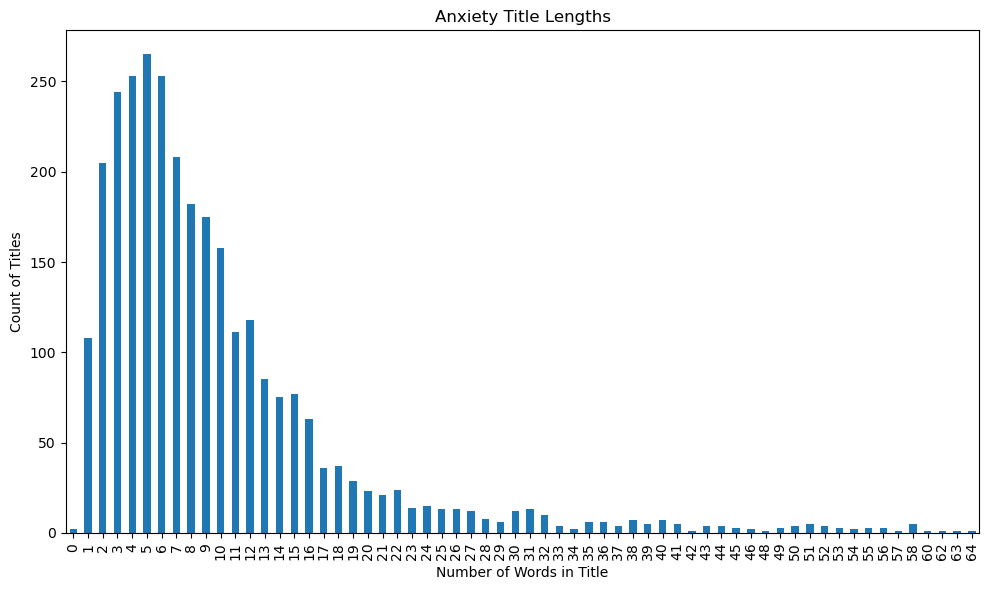

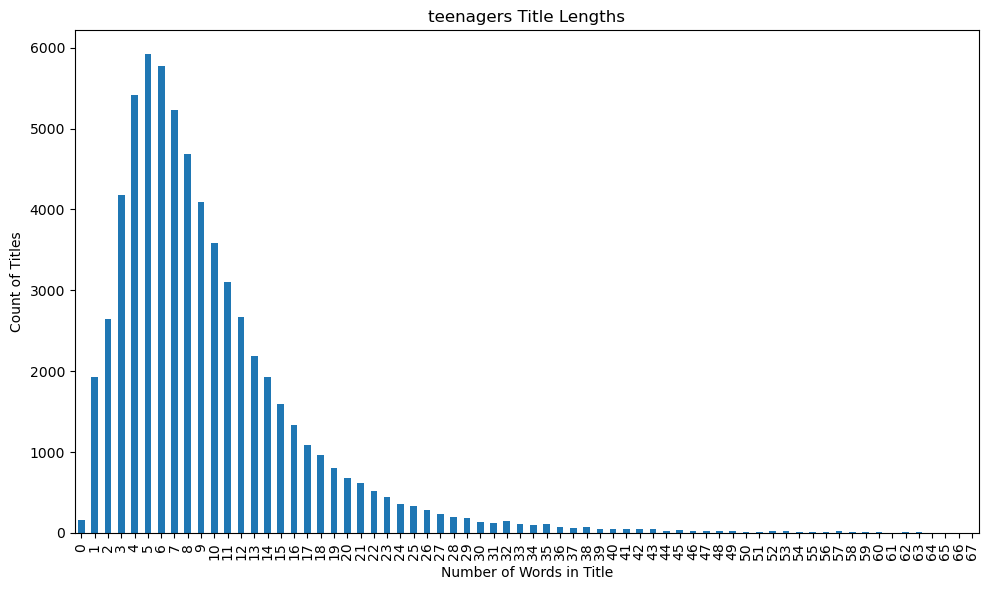

In [ ]:
for subreddit in full_df['subreddit'].unique():
    subreddit_df = full_df[full_df['subreddit'] == subreddit].copy()
    filtered = subreddit_df.loc[subreddit_df['selftext'] == '', 'title_length']
    filtered.value_counts().sort_index().plot(
        kind='bar',
        title=f'{subreddit} Title Lengths',
        xlabel='Number of Words in Title',
        ylabel='Count of Titles',
        figsize=(10, 6)
    )
    plt.tight_layout()
    plt.show()


In [39]:
suicidewatch = full_df[full_df.subreddit == 'SuicideWatch'].copy()
suicidewatch[(suicidewatch.title_length == 3) & (suicidewatch.selftext == '')]

,subreddit,title,selftext,title_length
8158,SuicideWatch,Holidays; a rant,,3
8195,SuicideWatch,My last night,,3
8214,SuicideWatch,I’m almost ready.,,3
8228,SuicideWatch,feeling tired today,,3
8252,SuicideWatch,Exit bag question,,3
...,...,...,...,...
22417,SuicideWatch,Alcohol and suicide,,3
22453,SuicideWatch,Nothing works anymore.,,3
22461,SuicideWatch,Nothing works anymore.,,3
22484,SuicideWatch,Done with everything,,3


In [67]:
askreddit = full_df[full_df.subreddit == 'AskReddit'].copy()
no_selftext_count = askreddit[askreddit['selftext'] == ''].shape[0]
print(f"Number of posts with no selftext: {no_selftext_count}")

Number of posts with no selftext: 284964


In [64]:
casualuk = full_df[full_df.subreddit == 'CasualUK'].copy()
casualuk[(casualuk.title_length == 1) & (casualuk.selftext != '')]

,subreddit,title,selftext,title_length
639,CasualUK,"Bluey,",Does anyone else find they get more parental a...,1
1314,CasualUK,Wellington.,"For those struggling with cost of living, call...",1
1447,CasualUK,Accents,I've been curious about this for a while and t...,1
1916,CasualUK,Cocaine,Was it always so normalised?\n\nI was out last...,1
2900,CasualUK,Shit,"After [this post]( a few days ago, I thought I...",1
3457,CasualUK,Fixter,Anyone used Fixter before? Interested in thou...,1
4549,CasualUK,Bins.,Why are people obsessed with their bins? My da...,1
4654,CasualUK,Heating,Is it best to boost the heating every few hour...,1
4880,CasualUK,RAGZ/RAGO,I was listening to the shitsngigs podcast and ...,1
5439,CasualUK,Unexpected,Why would anyone have a dolphin in the front s...,1


In [40]:
print(f"Total rows after filtering: {len(full_df)}")
print(f"ADHD rows: {len(full_df[full_df['subreddit'] == 'ADHD'])}")
print(f"Anxiety rows: {len(full_df[full_df['subreddit'] == 'Anxiety'])}")
print(f"AskReddit rows: {len(full_df[full_df['subreddit'] == 'AskReddit'])}")
print(f"CasualUK rows: {len(full_df[full_df['subreddit'] == 'CasualUK'])}")
print(f"SuicideWatch rows: {len(full_df[full_df['subreddit'] == 'SuicideWatch'])}")
print(f"Teenagers rows: {len(full_df[full_df['subreddit'] == 'teenagers'])}")

Total rows after filtering: 418908
ADHD rows: 13935
Anxiety rows: 8216
AskReddit rows: 284965
CasualUK rows: 8158
SuicideWatch rows: 14382
Teenagers rows: 89252


In [ ]:
mentalhealth = full_df[(full_df['subreddit'] == 'ADHD') |
                       (full_df['subreddit'] == 'Anxiety') |
                       (full_df['subreddit'] == 'SuicideWatch')]
normal = full_df[(full_df['subreddit'] == 'teenagers') |
                 (full_df['subreddit'] == 'CasualUK')]
# Remove rows with both empty title and selftext
mentalhealth = mentalhealth[~((mentalhealth['title'] == '') & (mentalhealth['selftext'] == ''))]
normal = normal[~((normal['title'] == '') & (normal['selftext'] == ''))]

In [99]:
mentalhealth_count = mentalhealth.shape[0]
normal_count = normal.shape[0]
print(f"Mental health posts: {mentalhealth_count}")
print(f"Normal posts: {normal_count}")

Mental health posts: 36518
Normal posts: 97227


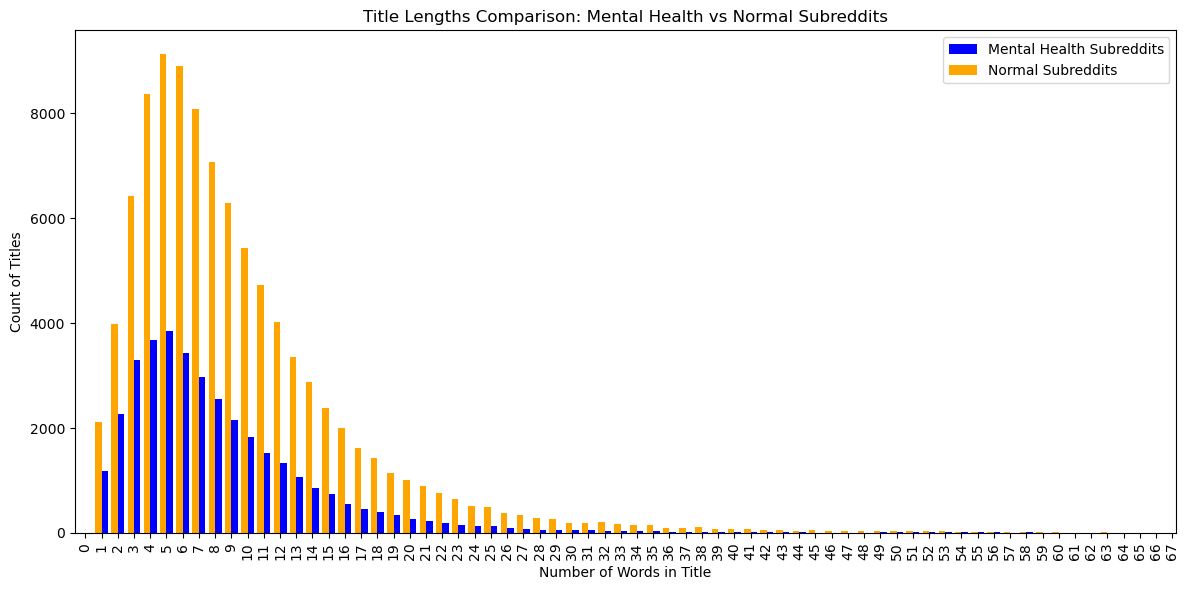

In [100]:
# Plot title lengths for mental health subreddits and normal subreddits on one graph
# The bars should be side by side
mental_health_counts = mentalhealth['title_length'].value_counts().sort_index()
normal_counts = normal['title_length'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
mental_health_counts.plot(kind='bar', width=0.4, position=0, label='Mental Health Subreddits', color='blue')
normal_counts.plot(kind='bar', width=0.4, position=1, label='Normal Subreddits', color='orange')
plt.title('Title Lengths Comparison: Mental Health vs Normal Subreddits')
plt.xlabel('Number of Words in Title')
plt.ylabel('Count of Titles')
plt.legend()
plt.tight_layout()
plt.show()

In [101]:
mentalhealth['label'] = '1'
normal['label'] = '0'
data = pd.concat([mentalhealth, normal])
data = data[['title', 'selftext', 'label']]
data.to_csv('full.csv', index=False)

Empty body in mental health: 17627
Empty body in normal: 70953


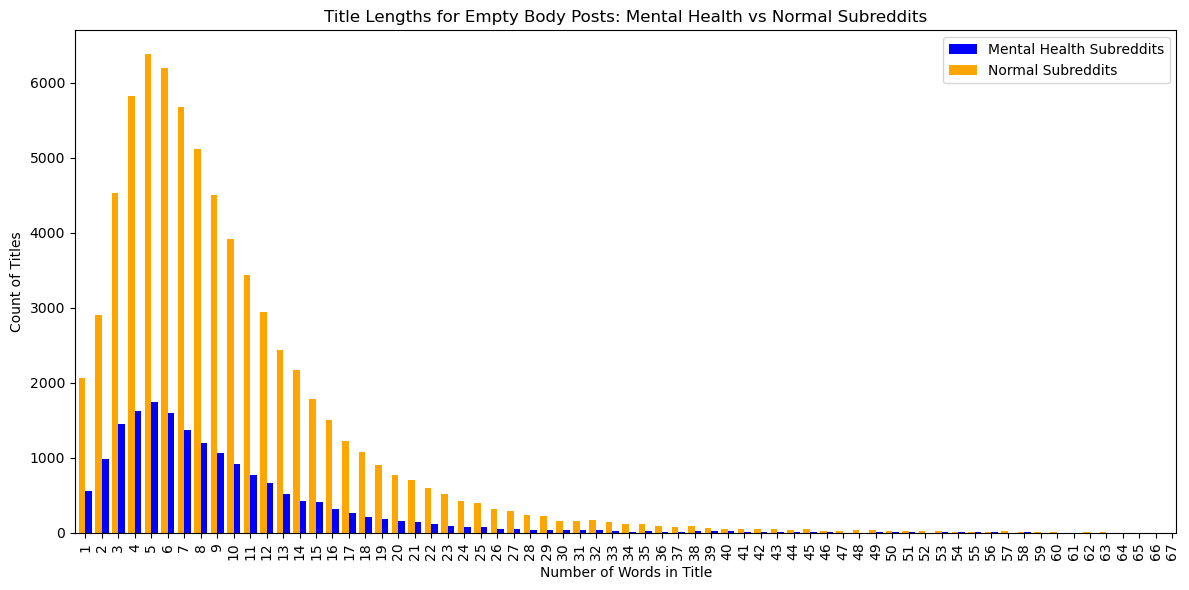

In [106]:
empty_body_mentalhealth = mentalhealth[(mentalhealth['title'] != '') & (mentalhealth['selftext'] == '')]
empty_body_normal = normal[(normal['title'] != '') & (normal['selftext'] == '')]
print(f"Empty body in mental health: {len(empty_body_mentalhealth)}")
print(f"Empty body in normal: {len(empty_body_normal)}")
# Plot title lengths for empty body posts in mental health and normal subreddits
plt.figure(figsize=(12, 6))
empty_body_mentalhealth['title_length'].value_counts().sort_index().plot(
    kind='bar', width=0.4, position=0, label='Mental Health Subreddits', color='blue')
empty_body_normal['title_length'].value_counts().sort_index().plot(
    kind='bar', width=0.4, position=1, label='Normal Subreddits', color='orange')
plt.title('Title Lengths for Empty Body Posts: Mental Health vs Normal Subreddits')
plt.xlabel('Number of Words in Title')
plt.ylabel('Count of Titles')
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
print("Examples of posts with empty body in normal subreddits:")
for index, row in empty_body_mentalhealth.iterrows():
    if len(row['title'].split()) == 2:
        print(f"Title: {row['title']}")
# print("Examples of posts with empty body in normal subreddits:")
# for index, row in empty_body_normal.iterrows():
#     if len(row['title'].split()) == 4:
#         print(f"Title: {row['title']}")

Examples of posts with empty body in normal subreddits:
Title: help me
Title: I've decided...
Title: Hey dudes
Title: Really struggling
Title: Suicide hotline
Title: carbon monoxide
Title: Still alivr
Title: I failed
Title: The Decision
Title: I tried
Title: Im sorry
Title: It's time
Title: Goodbye everyone
Title: F life….
Title: It’s over
Title: vent post
Title: Need Help
Title: Makeshift Beneficiary
Title: Makeshift beneficiary
Title: January th
Title: Bought gun
Title: Exit Bag
Title: I’m hopeless
Title: The Struggle
Title: I’m done
Title: im tired
Title: it hurts
Title: Homicidal ideation
Title: help me
Title: I'm selfish,
Title: Chaotic story
Title: I'm Done.
Title: Getting closer
Title: I confused
Title: It's weird
Title: Daily thoughts
Title: A year
Title: I'm tired
Title: Ignore me
Title: Bipolar  nsfw
Title: Damar Hamlin
Title: OD tonight
Title: January th
Title: Any tips?
Title: Please help
Title: I'm done
Title: Done in
Title: I’m weak
Title: Suicidal Thoughts
Title: the rew

In [118]:
full = pd.concat([mentalhealth, normal], ignore_index=True)
full.to_csv('full.csv', index=False)